In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "ml").is_dir() else NOTEBOOK_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "AI ResilienceLearn (Responses) - Form Responses 1 (1).csv"
df = pd.read_csv(DATA_PATH)

df.head()


Student/Admin User
        ↓
Frontend Dashboard UI (Streamlit / Web UI)
        ↓
FastAPI Backend API
        ├── Preprocessing Layer
        │     - column cleaning
        │     - ordinal encoding
        │     - missing value handling
        │     - feature engineering
        ↓
ML Prediction Layer
        - Linear Regression / Random Forest
        ↓
Explainability Layer
        - Feature Importance
        - SHAP / contribution analysis
        ↓
API Response
        - predicted mental health score
        - explanation of key contributing factors
        ↓
Frontend Display
        - score / risk level
        - top factors
        - suggested support insight

In [2]:
import os
os.getcwd()


'c:\\Users\\VICTUS\\Desktop\\ResilienceLearn_UI\\notebooks'

In [3]:
os.listdir("../data")

['AI ResilienceLearn (Responses) - Form Responses 1 (1).csv']

In [ ]:
# `ml.preprocessing` performs canonical column cleaning. Raw `df` from the CSV is enough here.
df.head(2)


In [ ]:
from ml.preprocessing import MODEL_FEATURE_ORDER, prepare_X_y_classification

X, y, proc = prepare_X_y_classification(df)
print("Features:", list(X.columns))
assert list(X.columns) == list(MODEL_FEATURE_ORDER)
X.shape, y.value_counts()


In [ ]:
# High-cardinality columns are dropped inside `prepare_X_y_classification`.
proc.head(2)


In [ ]:
print("Rows, Columns:", proc.shape)
display(proc.head(3))

missing = proc.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

uniq = proc.nunique().sort_values(ascending=False)
display(uniq)


In [ ]:
# Superseded: `risk_label` is created inside `prepare_X_y_classification` (same 1–2 vs 3–5 rule).
pass


In [ ]:
# Superseded: performance column is dropped inside shared preprocessing to avoid leakage.
pass


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
lr_model.fit(X_train, y_train)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]
y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression (baseline)")
print("  accuracy :", accuracy_score(y_test, y_pred_lr))
print("  precision:", precision_score(y_test, y_pred_lr, zero_division=0))
print("  recall   :", recall_score(y_test, y_pred_lr, zero_division=0))
print("  f1       :", f1_score(y_test, y_pred_lr, zero_division=0))
try:
    print("  roc_auc  :", roc_auc_score(y_test, y_proba_lr))
except ValueError as e:
    print("  roc_auc  : n/a ({})".format(e))


In [ ]:
# Train / test sets are shared with the baseline above.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = rf_model.predict(X_test)

print("Random Forest (main)")
print("  accuracy :", accuracy_score(y_test, y_pred_rf))
print("  precision:", precision_score(y_test, y_pred_rf, zero_division=0))
print("  recall   :", recall_score(y_test, y_pred_rf, zero_division=0))
print("  f1       :", f1_score(y_test, y_pred_rf, zero_division=0))
try:
    print("  roc_auc  :", roc_auc_score(y_test, y_proba_rf))
except ValueError as e:
    print("  roc_auc  : n/a ({})".format(e))


In [ ]:
import joblib

ART = PROJECT_ROOT / "artifacts"
ART.mkdir(parents=True, exist_ok=True)

_feature_importances = {
    name: float(imp)
    for name, imp in zip(X.columns, rf_model.feature_importances_, strict=True)
}
_feature_medians = X_train.median().astype(float).to_dict()

payload = {
    "model": rf_model,
    "feature_names": list(X.columns),
    "target": "risk_label",
    "positive_class": 1,
    "positive_label": "at_risk",
    "feature_importances": _feature_importances,
    "feature_medians": _feature_medians,
}
joblib.dump(payload, ART / "model.joblib")
print("Saved", ART / "model.joblib")


**Classification (academic risk).** Baseline: Logistic Regression; main model: Random Forest. Metrics on held-out test: accuracy, precision, recall, F1, ROC-AUC. The Random Forest artifact is saved as rtifacts/model.joblib for the API.


In [ ]:
import pandas as pd

importance = rf_model.feature_importances_
feat_imp = pd.Series(importance, index=X.columns).sort_values(ascending=False)

print("Feature importance (Random Forest)")
print(feat_imp)


what affects mental health the most:The higher the feature appears → the more important it is.
“Feature importance analysis revealed that academic motivation, exposure to economic or political crises, and academic stress are the most influential factors affecting students’ mental health. Sleep duration also plays a significant role, while environmental factors such as internet stability and study environment were less impactful. This suggests that psychological and socio-economic factors dominate over physical study conditions.”

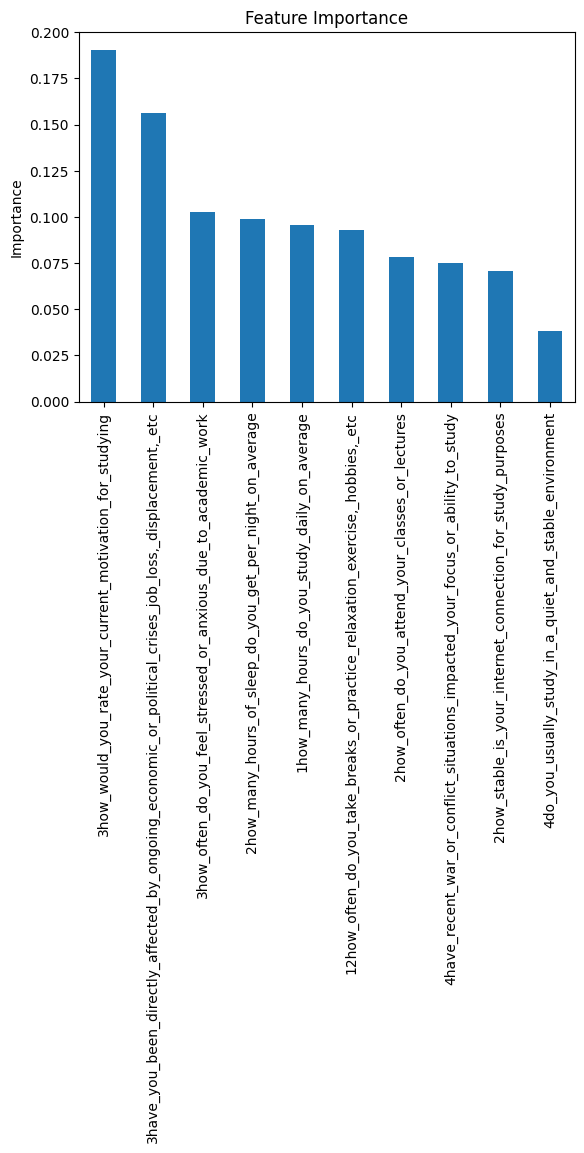

In [17]:
import matplotlib.pyplot as plt

feat_imp.plot(kind="bar")
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.xticks(rotation=90)
plt.show()

The graph is showing: Each bar = how important a feature is